● Explore the data, list down the unique values in each feature and find its length.
● Perform the statistical analysis and renaming of the columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Employee.csv")
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(148, 6)
<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    str    
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    str    
 4   Country  148 non-null    str    
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 9.4 KB
None
              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.000000    0.000000
75%     37.750000  8000.000000    0.000000
max     54.000000  9876.000000    1.000000


In [6]:
for col in df.columns:
    print(col,":", df[col].unique())
    print("Length:", df[col].nunique())

Company : <ArrowStringArray>
[                      'TCS',                   'Infosys',
                       'CTS',                         nan,
 'Tata Consultancy Services',                'Congnizant',
           'Infosys Pvt Lmt']
Length: 7, dtype: str
Length: 6
Age : [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29
Salary : [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length: 40
Place : <ArrowStringArray>
[   'Chennai',     'Mumbai',   'Calcutta',      'Delhi', 'Podicherry',
     'Cochin',          nan,      'Noida',  'Hyderabad',     'Bhopal',
     'Nagpur',       'Pune']
Length: 12, dtype: str
Length: 11
Country : <ArrowStringArray>
['India']
Length: 1, dtype: str
Length: 1
Gender : [0 1]
Len

In [7]:
df.rename(columns={
    'Company':'company',
    'Age':'age',
    'Salary':'salary',
    'Place':'place',
    'Country':'country',
    'Gender':'gender'
}, inplace=True)

df.head()

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [9]:
print(df.isnull().sum())

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64


In [10]:
df['age']=df['age'].fillna(df['age'].median())
df['salary']=df['salary'].fillna(df['salary'].median())
df['company']=df['company'].fillna(df['company'].mode()[0])
df['place']=df['place'].fillna(df['place'].mode()[0])

In [11]:
print(df.isnull().sum())

company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['age']=df['age'].replace(0, np.nan)

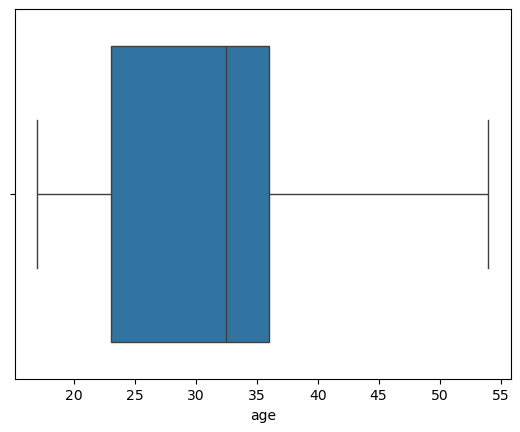

In [16]:
sns.boxplot(x=df['age'])
plt.show()

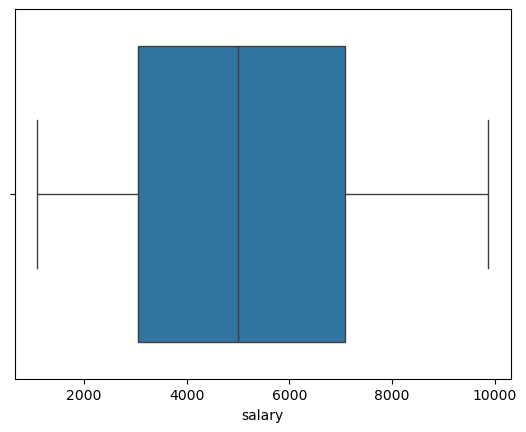

In [15]:
sns.boxplot(x=df['salary'])
plt.show()

● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

In [18]:
filtered=df[(df['age'] > 40) & (df['salary'] < 5000)]
filtered

,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


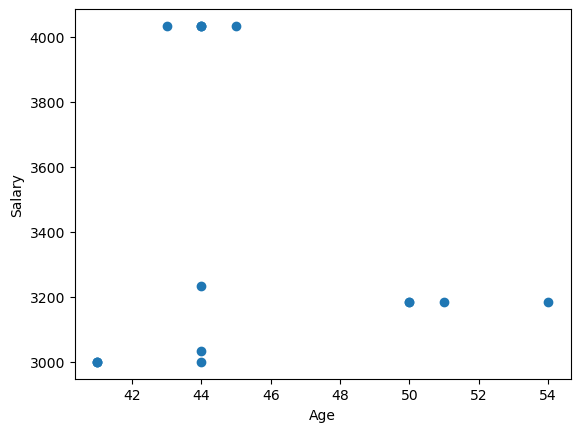

In [22]:
plt.scatter(filtered['age'],filtered['salary'])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

In [26]:
place_count=df['place'].value_counts()
place_count

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64

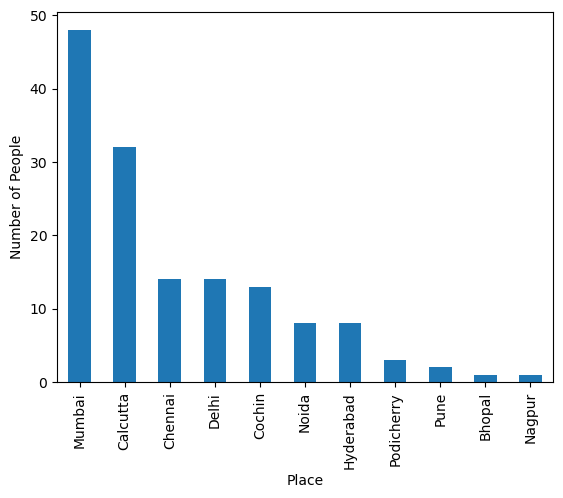

In [28]:
place_count.plot(kind='bar')
plt.xlabel("Place")
plt.ylabel("Number of People")
plt.show()

● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [32]:
df_encoded=pd.get_dummies(df,columns=['company','place','country'],dtype=int)
df_encoded.head()

,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,...,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,20.0,5000.0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,30.0,5000.0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,35.0,2300.0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,40.0,3000.0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,23.0,4000.0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1


● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df_encoded[['age','salary']]=scaler.fit_transform(df_encoded[['age','salary']])
df_encoded.head()

,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,...,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,-1.442988,-0.100827,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,-0.250222,-0.100827,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.346161,-1.243735,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.942544,-0.947426,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,-1.085158,-0.524127,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
df_encoded[['age','salary']]=scaler.fit_transform(df_encoded[['age','salary']])

df_encoded.head()

,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,...,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,0.081081,0.445089,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0.351351,0.445089,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.486486,0.137817,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.621622,0.217480,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,0.162162,0.331285,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
